In [17]:
import altair as alt 
import pandas as pd
import numpy as np

In [18]:
import sys
sys.path.insert(0, '..')

from dataloader import load_df, load_sensitivity, PARAMS, load_sensitivity_perframe, load_perframe_pervalue, PARAM_LABELS

In [19]:
df          = load_df("../dataset.json")
sensitivity = load_sensitivity("../dataset.json")
sensitivity_perframe = load_sensitivity_perframe("../dataset.json")

/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_center_group)
/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_center_group)
/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:224: FutureWarning: DataFram

# Understanding Sensitivity

In [20]:
sensitivity_perframe = load_sensitivity_perframe("../dataset.json")

charts = []
for metric, title in [
    ('sensitivity_best_std',  'Std of best frames'),
    ('sensitivity_worst_std', 'Std of worst frames'),
]:
    agg = sensitivity_perframe.groupby(['parameter', 'resolution'])[metric].mean().reset_index()
    
    chart = alt.Chart(agg).mark_line(point=True).encode(
        x=alt.X('resolution:O', title='Resolution (%)'),
        y=alt.Y(f'{metric}:Q', title=f'Mean sensitivity ({title})', scale=alt.Scale(zero=False)),
        color=alt.Color('parameter:N', title='Parameter'),
        tooltip=['parameter', 'resolution', metric],
    ).properties(
        title=title,
        width=300,
        height=250
    )
    charts.append(chart)

(charts[0] | charts[1]).resolve_scale(
    y='shared'
).properties(
    title='Sensitivity: best vs worst frames'
)

/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:224: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_sensitivity)


alt.HConcatChart(...)

In [21]:
sensitivity_perframe = load_sensitivity_perframe("../dataset.json")

for metric, title in [
    ('sensitivity_best_std',  'std of best frames'),
    ('sensitivity_worst_std', 'std of worst frames'),
]:
    agg = sensitivity_perframe.groupby(['parameter', 'resolution'])[metric].mean().reset_index()
    
    alt.Chart(agg).mark_line(point=True).encode(
        x=alt.X('resolution:O', title='Resolution (%)'),
        y=alt.Y(f'{metric}:Q', title=f'Mean sensitivity ({title})', 
                scale=alt.Scale(zero=False, domain=[0, 8])),
        color=alt.Color('parameter:N', title='Parameter'),
        tooltip=['parameter', 'resolution', metric]
    ).properties(
        title=f'Sensitivity ({title}) per parameter across resolutions',
        width=400,
        height=300
    ).display()

/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:224: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_sensitivity)


alt.Chart(...)

alt.Chart(...)

In [22]:
df_pervalue = load_perframe_pervalue("../dataset.json")

df_pervalue['sensitivity'] = df_pervalue['quality_best'] - df_pervalue['quality_worst']

agg = df_pervalue.groupby(['parameter', 'resolution'])['sensitivity'].mean().reset_index()

alt.Chart(agg).mark_line(point=True).encode(
    x=alt.X('resolution:O', title='Resolution (%)'),
    y=alt.Y('sensitivity:Q', title='Mean sensitivity (best - worst frames)', scale=alt.Scale(zero=False)),
    color=alt.Color('parameter:N', title='Parameter'),
    tooltip=['parameter', 'resolution', 'sensitivity']
).properties(
    title='Sensitivity (best - worst frame quality) per parameter across resolutions',
    width=400,
    height=300
)

alt.Chart(...)

In [23]:
df_pervalue = load_perframe_pervalue("../dataset.json")

df_pervalue['sensitivity'] = df_pervalue['quality_best'] - df_pervalue['quality_worst']

agg = df_pervalue.groupby(['parameter', 'resolution'])['sensitivity'].std().reset_index()

alt.Chart(agg).mark_line(point=True).encode(
    x=alt.X('resolution:O', title='Resolution (%)'),
    y=alt.Y('sensitivity:Q', title='Std of (best - worst frames)', scale=alt.Scale(zero=False)),
    color=alt.Color('parameter:N', title='Parameter'),
    tooltip=['parameter', 'resolution', 'sensitivity']
).properties(
    title='Std of per-frame sensitivity per parameter across resolutions',
    width=400,
    height=300
)

alt.Chart(...)

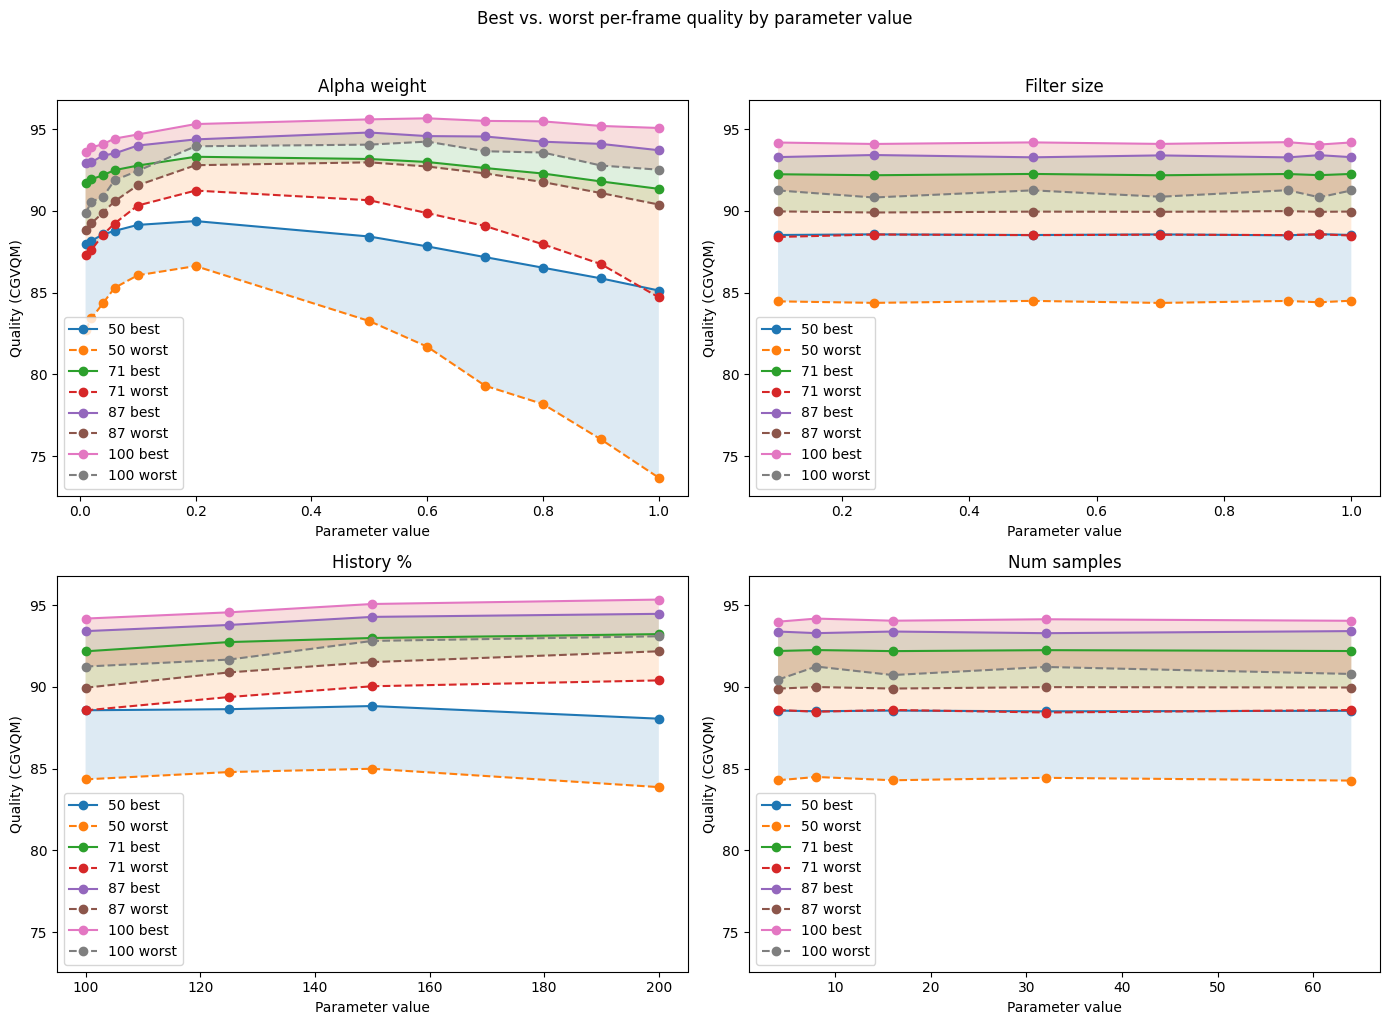

In [24]:
# After calling load_perframe_pervalue
df_pervalue = load_perframe_pervalue("../dataset.json")

# For each (resolution, parameter, value), get mean best and worst quality across scenes
agg = df_pervalue.groupby(['resolution', 'parameter', 'value']).agg(
    mean_best=('quality_best', 'mean'),
    mean_worst=('quality_worst', 'mean'),
).reset_index()

agg['range'] = agg['mean_best'] - agg['mean_worst']

y_min = agg[['mean_best', 'mean_worst']].min().min()
y_max = agg[['mean_best', 'mean_worst']].max().max()
margin = (y_max - y_min) * 0.05  # 5% padding

def plot_best_worst(df, param, ax):
    df_param = df[df['parameter'] == param]
    for res, grp in df_param.groupby('resolution'):
        ax.plot(grp['value'], grp['mean_best'],  label=f'{res} best',  marker='o')
        ax.plot(grp['value'], grp['mean_worst'], label=f'{res} worst', marker='o', linestyle='--')
        ax.fill_between(grp['value'], grp['mean_worst'], grp['mean_best'], alpha=0.15)
    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Quality (CGVQM)')
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, param in zip(axes.flatten(), PARAMS):
    plot_best_worst(agg, param, ax)
plt.suptitle('Best vs. worst per-frame quality by parameter value', y=1.02)
plt.tight_layout()
plt.show()

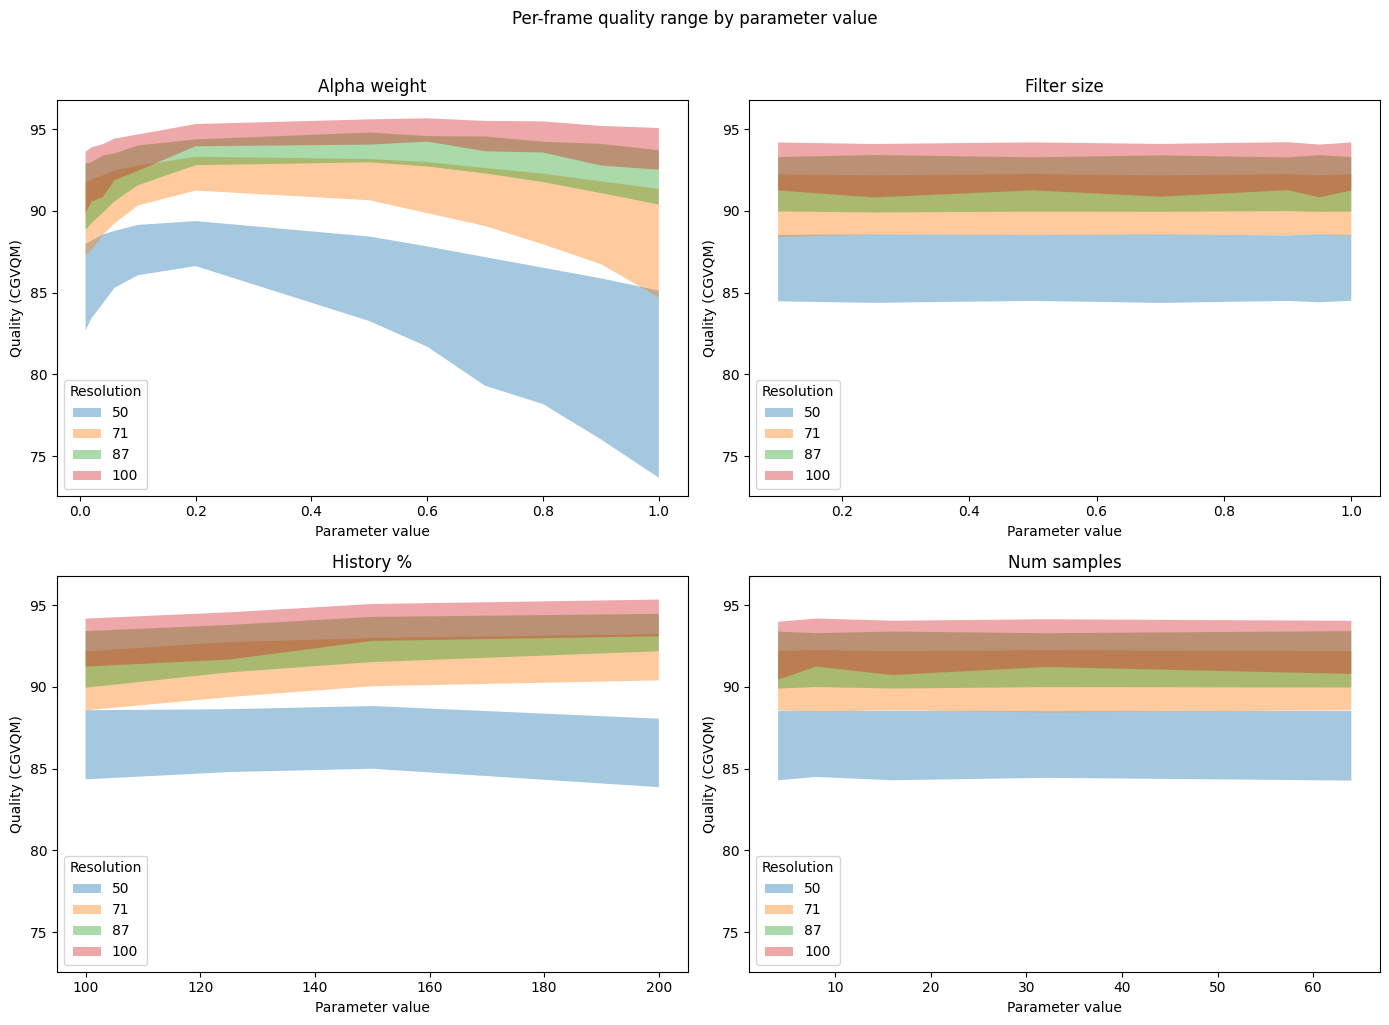

In [25]:
def plot_range_only(df, param, ax):
    df_param = df[df['parameter'] == param]
    for res, grp in df_param.groupby('resolution'):
        ax.fill_between(grp['value'], grp['mean_worst'], grp['mean_best'], alpha=0.4, label=res)
    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Quality (CGVQM)')
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.legend(title='Resolution')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, param in zip(axes.flatten(), PARAMS):
    plot_range_only(agg, param, ax)
plt.suptitle('Per-frame quality range by parameter value', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# First compute mean quality per (scene, resolution, parameter, value)
agg['mean_quality'] = (agg['mean_best'] + agg['mean_worst']) / 2

# Mean-center across parameter values for each (scene, resolution, parameter)
agg['centered_quality'] = agg.groupby(
    ['scene', 'resolution', 'parameter'])['mean_quality'].transform(
    lambda x: x - x.mean())

# Compute range of centered quality per (scene, resolution, parameter)
centered_ranges = agg.groupby(['scene', 'resolution', 'parameter'])['centered_quality'].apply(
    lambda x: x.max() - x.min()).reset_index()
centered_ranges.columns = ['scene', 'resolution', 'parameter', 'centered_range']

# Average range across scenes per (resolution, parameter)
table = centered_ranges.groupby(['resolution', 'parameter'])['centered_range'].mean().unstack('parameter')

# Reorder columns and rows to match your existing table
table = table[['alpha_weight', 'filter_size', 'hist_pct', 'num_samples']]
table = table.sort_values('resolution', ascending=False)

print(table.round(2))

KeyError: 'scene'

In [28]:
# Average sensitivity across scenes for each (parameter, resolution)
agg = sensitivity.groupby(['parameter', 'resolution'])['sensitivity_std'].mean().reset_index()

chart = alt.Chart(agg).mark_line(point=True).encode(
    x=alt.X('resolution:O', title='Resolution (%)'),
    y=alt.Y('sensitivity_std:Q', title='Mean sensitivity (std)'),
    color=alt.Color('parameter:N', title='Parameter'),
    tooltip=['parameter', 'resolution', 'sensitivity_std']
).properties(
    title='Mean sensitivity per parameter across resolutions',
    width=400,
    height=300
)

chart

alt.Chart(...)

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

agg_stats = df_pervalue.groupby(['parameter', 'value', 'resolution'])['sensitivity'].agg(['mean', 'std']).reset_index()

y_min = 0
y_max = (agg_stats['mean']).max() + 5

def plot_sensitivity_by_param(df_pervalue, param, ax):
    df_param = df_pervalue[df_pervalue['parameter'] == param]
    sns.lineplot(
        data=df_param,
        x='value',
        y='sensitivity',
        hue='resolution',
        marker='o',
        ax=ax
    )
    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Sensitivity (best - worst frames)')
    ax.set_ylim(y_min, y_max)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, param in zip(axes.flatten(), PARAMS):
    plot_sensitivity_by_param(df_pervalue, param, ax)

plt.suptitle('Sensitivity (best - worst frames) per parameter', y=1.02)
plt.tight_layout()
plt.show()

KeyError: 'Column not found: sensitivity'

/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:103: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



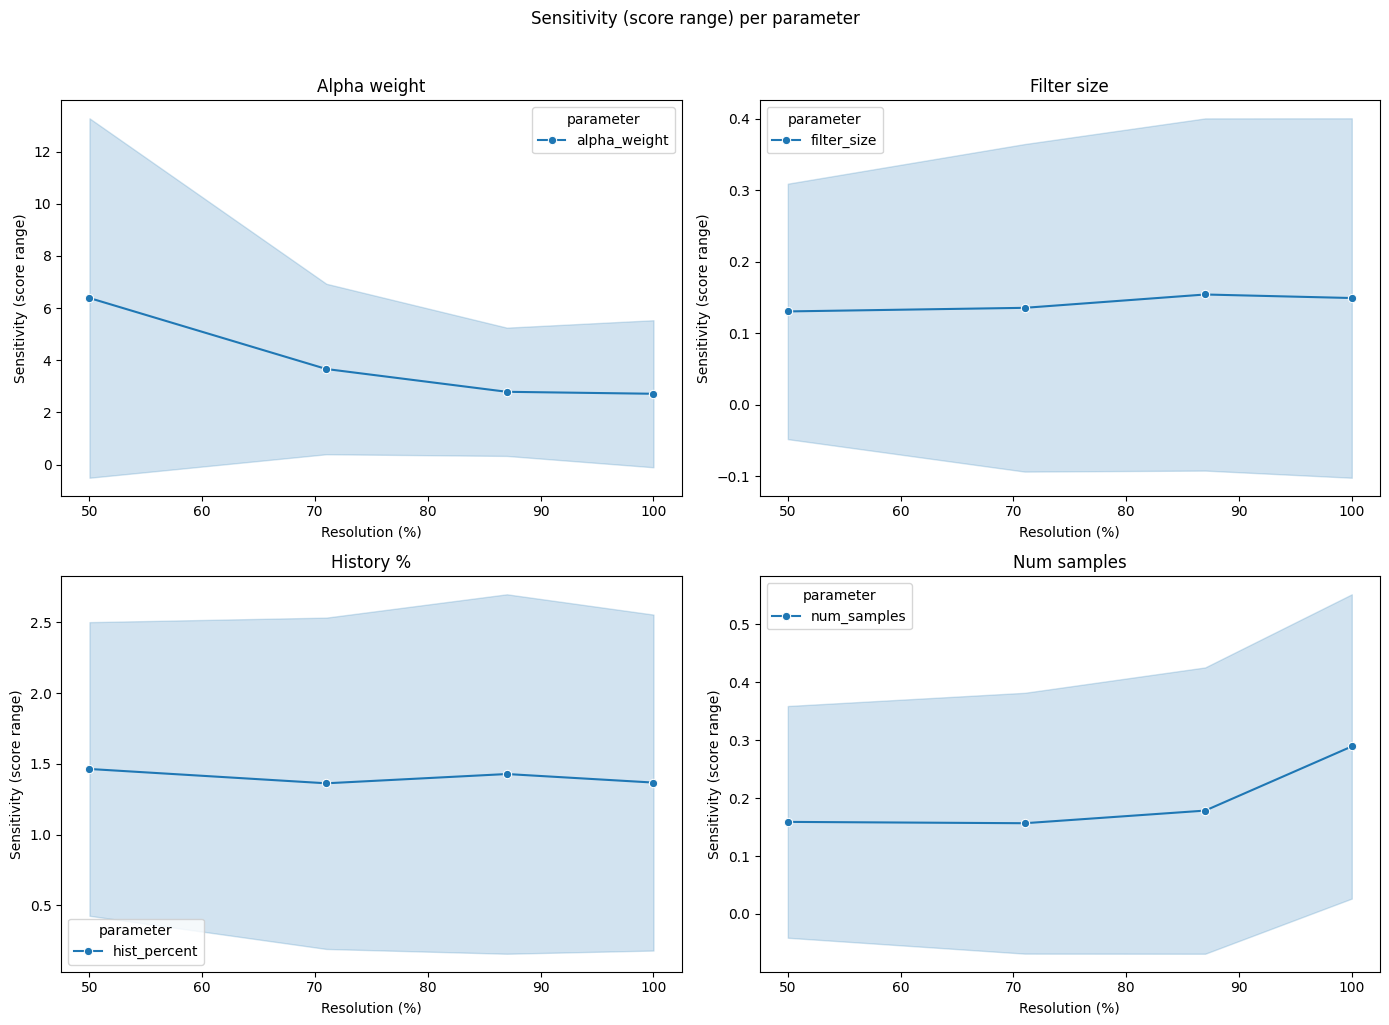

In [142]:
from dataloader import load_sensitivity, PARAM_LABELS, PARAMS

sensitivity = load_sensitivity("../dataset.json")

def plot_sensitivity_range_by_param(sensitivity, param, ax):
    df_param = sensitivity[sensitivity['parameter'] == param]
    sns.lineplot(
        data=df_param,
        x='resolution',
        y='sensitivity_range',
        hue='parameter',
        marker='o',
        errorbar='sd',
        ax=ax
    )
    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Resolution (%)')
    ax.set_ylabel('Sensitivity (score range)')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, param in zip(axes.flatten(), PARAMS):
    plot_sensitivity_range_by_param(sensitivity, param, ax)

plt.suptitle('Sensitivity (score range) per parameter', y=1.02)
plt.tight_layout()
plt.show()

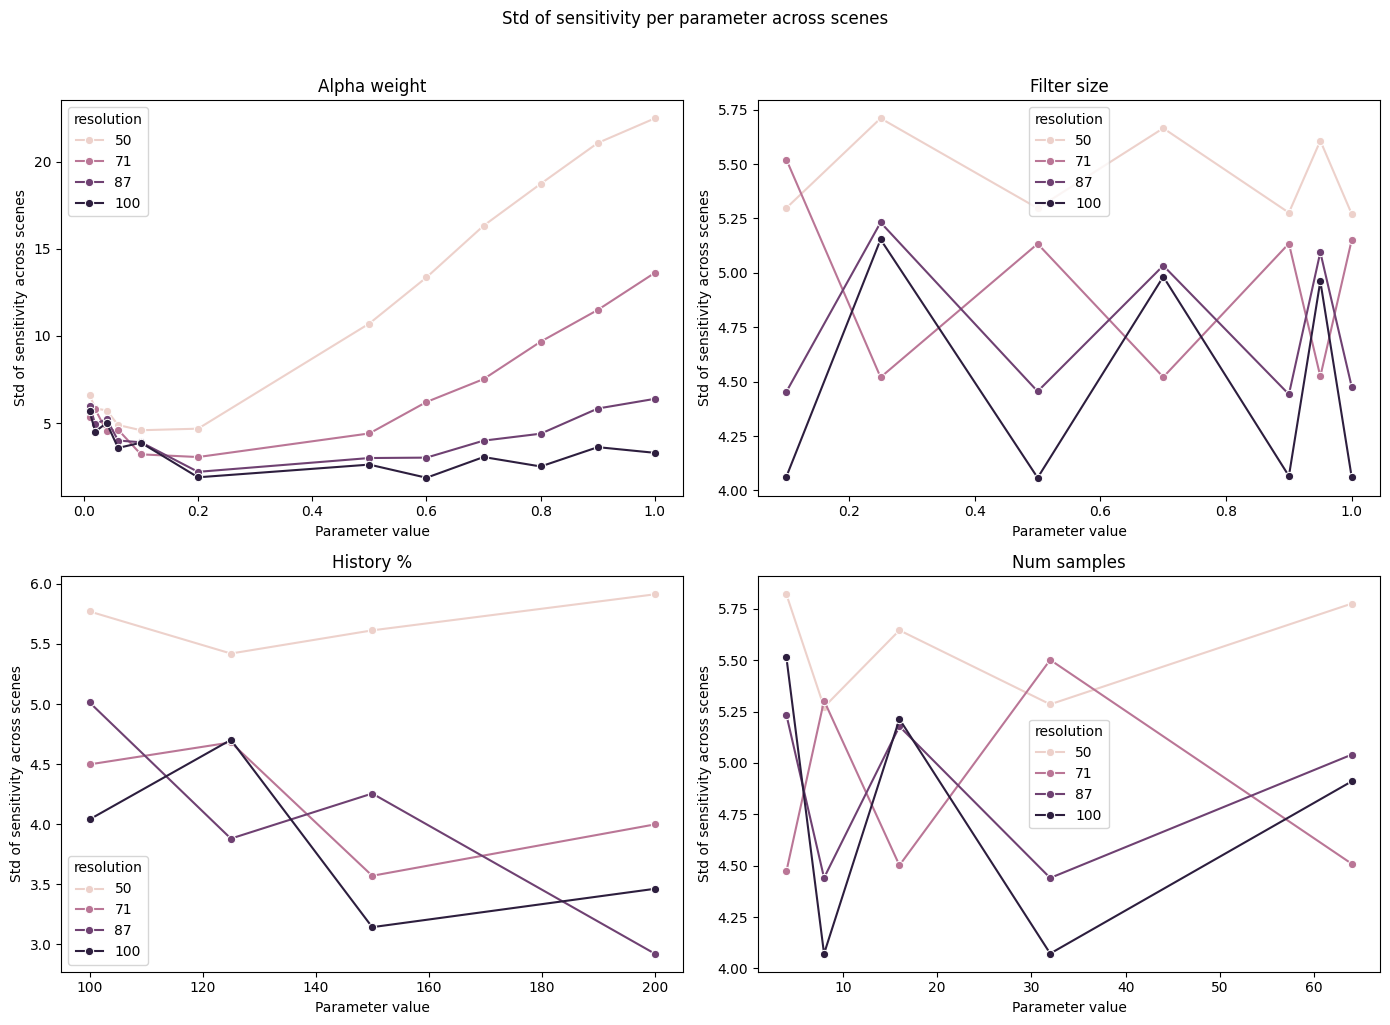

In [143]:
def plot_sensitivity_std_by_param(df_pervalue, param, ax):
    df_param = df_pervalue[df_pervalue['parameter'] == param]
    agg = (
        df_param.groupby(['value', 'resolution'])['sensitivity']
        .std()
        .reset_index()
    )
    sns.lineplot(
        data=agg,
        x='value',
        y='sensitivity',
        hue='resolution',
        marker='o',
        ax=ax
    )
    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Std of sensitivity across scenes')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, param in zip(axes.flatten(), PARAMS):
    plot_sensitivity_std_by_param(df_pervalue, param, ax)

plt.suptitle('Std of sensitivity per parameter across scenes', y=1.02)
plt.tight_layout()
plt.show()

In [144]:
import json
import altair as alt
import pandas as pd

with open('../dataset.json', 'r') as f:
    raw = json.load(f)

scene = 'lightfoliage-close'
res   = '100'
param = 'alpha_weight'

records = []
for entry in raw[scene][res][f'ref-{scene}'][param]:
    for frame_idx, error in enumerate(entry['per_frame_errors']):
        records.append({
            'frame': frame_idx,
            'error': error,
            'value': entry['value'],
        })

df_frames = pd.DataFrame(records)

# Exclude frames within 3 of a multiple of 30
df_frames = df_frames[df_frames['frame'].apply(lambda f: (f % 30) > 0 and (f % 30) < 28)]

alt.Chart(df_frames).mark_line(opacity=0.6, strokeWidth=1).encode(
    x=alt.X('frame:Q', title='Frame'),
    y=alt.Y('error:Q', title='Per-frame error (lower = better)'),
    color=alt.Color('value:O', title='alpha_weight value'),
    tooltip=['frame', 'error', 'value']
).properties(
    title=f'{scene} — {param} — resolution {res}% (boundary frames excluded)',
    width=500,
    height=300
)

alt.Chart(...)

# Loading Features

In [145]:
import altair as alt
import pandas as pd
from dataloader import load_sensitivity

# ── Load data ────────────────────────────────────────────────────────────────

features = pd.read_csv('video_stats.csv')
features['scene'] = features['filename'].str.replace('-demo.mp4', '').str.replace('.mp4', '')
features = features.drop(columns=['filename', 'error'])
features = features.rename(columns={
    'SI':  'spatial_info',
    'TI':  'temporal_info',
    'CF':  'colorfulness',
    'TP':  'texture',
    'MV':  'motion',
    'DTP': 'dynamic_texture',
})
features['scene'] = features['scene'].replace('fantasticvillage', 'fantasticvillage-open')

sensitivity = load_sensitivity('dataset.json')

# Merge
df = sensitivity.merge(features, on='scene')

FEATURE_COLS = ['spatial_info', 'temporal_info', 'colorfulness', 'texture', 'motion', 'dynamic_texture']
PARAM_LABELS = {
    'alpha_weight': 'Alpha weight',
    'filter_size':  'Filter size',
    'hist_percent': 'History %',
    'num_samples':  'Num samples',
}

FileNotFoundError: [Errno 2] No such file or directory: 'dataset.json'

In [146]:
sensitivity_perframe = load_sensitivity_perframe("../dataset.json")
sensitivity_perframe = sensitivity_perframe.merge(features, on='scene')

records = []
for param in PARAMS:
    for res in [50, 71, 87, 100]:
        df_sub = sensitivity_perframe[
            (sensitivity_perframe['parameter'] == param) & 
            (sensitivity_perframe['resolution'] == res)
        ]
        for feature in FEATURE_COLS:
            rho, pval = stats.spearmanr(df_sub[feature], df_sub['sensitivity_pct_range'])
            records.append({
                'parameter': param,
                'resolution': res,
                'feature': feature,
                'rho': rho,
                'pval': pval,
            })

corr = pd.DataFrame(records)
corr_agg = corr.groupby(['parameter', 'feature'])['rho'].mean().reset_index()

alt.Chart(corr).mark_bar().encode(
    x=alt.X('rho:Q', title='Spearman ρ', scale=alt.Scale(domain=[-1, 1])),
    y=alt.Y('feature:N', title=None),
    color=alt.Color('rho:Q', scale=alt.Scale(scheme='redblue', domain=[-1, 1]), title='ρ'),
    row=alt.Row('resolution:O', title='Resolution (%)'),
    column=alt.Column('parameter:N', title='Parameter'),
).properties(
    width=200,
    height=100
).resolve_scale(x='shared')

# alt.Chart(corr_agg).mark_bar().encode(
#     x=alt.X('rho:Q', title='Spearman ρ', scale=alt.Scale(domain=[-1, 1])),
#     y=alt.Y('feature:N', title=None),
#     color=alt.Color('rho:Q', scale=alt.Scale(scheme='redblue', domain=[-1, 1]), title='ρ'),
#     facet=alt.Facet('parameter:N', columns=2)
# ).properties(
#     width=250,
#     height=150
# ).resolve_scale(x='shared')


/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:217: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



alt.Chart(...)

In [ ]:
features[FEATURE_COLS].corr(method='spearman')

In [147]:
df = load_df("../dataset.json")
df_pervalue = load_perframe_pervalue("../dataset.json")

# merge features into both
df = df.merge(features, on='scene')
df_pervalue = df_pervalue.merge(features, on='scene')

records = []
for param in PARAMS:
    for res in [50, 71, 87, 100]:
        for val in df[df['parameter'] == param]['value'].unique():
            df_sub = df[
                (df['parameter'] == param) & 
                (df['resolution'] == res) & 
                (df['value'] == val)
            ]
            for feature in FEATURE_COLS:
                rho_mean, _ = stats.spearmanr(df_sub[feature], df_sub['score'])
                records.append({
                    'parameter': param,
                    'resolution': res,
                    'value': val,
                    'feature': feature,
                    'rho_mean': rho_mean,
                })
                
alt.Chart(pd.DataFrame(records)).mark_line(point=True).encode(
    x=alt.X('value:Q', title='Parameter value'),
    y=alt.Y('rho_mean:Q', title='Spearman ρ', scale=alt.Scale(domain=[-1, 1])),
    color=alt.Color('feature:N', title='Feature'),
    row=alt.Row('resolution:O', title='Resolution (%)'),
    column=alt.Column('parameter:N', title='Parameter'),
    tooltip=['feature', 'value', 'resolution', 'parameter', 'rho_mean']
).properties(
    width=150,
    height=100
).resolve_scale(
    x='independent'
)


/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:103: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



alt.Chart(...)

In [ ]:
sensitivity = load_sensitivity('../dataset.json')  # has sensitivity_std, sensitivity_range
df = sensitivity.merge(features, on='scene')    # merge onto THIS, not load_df output

In [ ]:
print(df.columns.tolist())


In [172]:
import altair as alt
import pandas as pd
from scipy import stats
from dataloader import load_sensitivity

# ── Load data ─────────────────────────────────────────────────────────────────
features = pd.read_csv('video_stats.csv')
features['scene'] = features['filename'].str.replace('-demo.mp4', '').str.replace('.mp4', '')
features = features.drop(columns=['filename', 'error'])
features = features.rename(columns={
    'SI':  'spatial_info',
    'TI':  'temporal_info',
    'CF':  'colorfulness',
    'TP':  'texture',
    'MV':  'motion',
    'DTP': 'dynamic_texture',
})
features['scene'] = features['scene'].replace('fantasticvillage', 'fantasticvillage-open')
sensitivity = load_sensitivity('../dataset.json')

df = sensitivity.merge(features, on='scene')

FEATURE_COLS = ['spatial_info', 'temporal_info', 'colorfulness', 'texture', 'motion', 'dynamic_texture']
PARAM_LABELS = {
    'alpha_weight': 'Alpha weight',
    'filter_size':  'Filter size',
    'hist_percent': 'History %',
    'num_samples':  'Num samples',
}

df_scatter = df.copy()
df_scatter['parameter'] = df_scatter['parameter'].map(PARAM_LABELS)

df_melt = df_scatter.melt(
    id_vars=['scene', 'resolution', 'parameter', 'sensitivity_std', 'sensitivity_range'],
    value_vars=FEATURE_COLS,
    var_name='feature',
    value_name='feature_value',
)

df_melt['resolution'] = df_melt['resolution'].astype(str) + '%'
res_order  = ['100%', '87%', '71%', '50%']
res_colors = ['#2a7db5', '#2ca05a', '#e07b3d', '#d4504a']
color_scale = alt.Scale(domain=res_order, range=res_colors)

# ── Pearson correlations per (feature × parameter) cell ───────────────────────
corr_rows = []
# for (feat, param), grp in df_melt.groupby(['feature', 'parameter']):
#     clean = grp[['feature_value', 'sensitivity_std']].dropna()
#     if len(clean) > 2:
#         r, p = stats.pearsonr(clean['feature_value'], clean['sensitivity_std'])
#     else:
#         r, p = float('nan'), float('nan')
#     corr_rows.append({'feature': feat, 'parameter': param, 'pearson_r': r, 'p_value': p})


for (feat, param), grp in df_melt.groupby(['feature', 'parameter']):
    clean = grp.groupby('scene')[['feature_value', 'sensitivity_range']].mean().dropna()
    if len(clean) > 2:
        r, p = stats.pearsonr(clean['feature_value'], clean['sensitivity_range'])
    else:
        r, p = float('nan'), float('nan')
    corr_rows.append({'feature': feat, 'parameter': param, 'pearson_r': r, 'p_value': p})

df_corr = pd.DataFrame(corr_rows)
df_corr['label'] = df_corr.apply(
    lambda row: f"r = {row['pearson_r']:+.2f}{'*' if row['p_value'] < 0.05 else ''}",
    axis=1,
)

# Top-right anchor: use per-feature x max
x_maxs = df_melt.groupby('feature')['feature_value'].max().rename('x_anchor')
df_corr = df_corr.join(x_maxs, on='feature')

# ── Join back so both layers share one dataframe ──────────────────────────────
df_melt = df_melt.merge(df_corr[['feature', 'parameter', 'label', 'x_anchor']],
                         on=['feature', 'parameter'], how='left')

base = alt.Chart(df_melt)

scatter_layer = (
    base
    .mark_circle(size=55, opacity=0.65)
    .encode(
        x=alt.X('feature_value:Q', title=None, scale=alt.Scale(zero=False)),
        y=alt.Y('sensitivity_range:Q', title='Sensitivity (std)'),
        color=alt.Color('resolution:N', title='Resolution',
                        scale=color_scale, sort=res_order),
        tooltip=['scene', 'parameter', 'resolution', 'feature',
                 alt.Tooltip('feature_value:Q', format='.2f'),
                 alt.Tooltip('sensitivity_range:Q', format='.3f')],
    )
)

corr_layer = (
    base
    .mark_text(align='right', baseline='top', fontSize=9, color='#333333', fontStyle='italic')
    .encode(
        x=alt.X('x_anchor:Q', scale=alt.Scale(zero=False)),
        y=alt.value(4),
        text=alt.Text('label:N'),
    )
)

scatter = (
    (scatter_layer + corr_layer)
    .properties(width=160, height=130)
    .facet(
        row=alt.Row('feature:N', sort=FEATURE_COLS,
                    header=alt.Header(labelAngle=0, labelAlign='left', labelLimit=200)),
        column=alt.Column('parameter:N', sort=list(PARAM_LABELS.values())),
    )
    .resolve_scale(x='independent')
)

scatter

/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:103: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



alt.FacetChart(...)

In [186]:
import altair as alt
import pandas as pd
from scipy import stats
from dataloader import load_sensitivity

# ── Load data ─────────────────────────────────────────────────────────────────
features = pd.read_csv('video_stats.csv')
features['scene'] = features['filename'].str.replace('-demo.mp4', '').str.replace('.mp4', '')
features = features.drop(columns=['filename', 'error'])
features = features.rename(columns={
    'SI':  'spatial_info',
    'TI':  'temporal_info',
    'CF':  'colorfulness',
    'TP':  'texture',
    'MV':  'motion',
    'DTP': 'dynamic_texture',
})
features['scene'] = features['scene'].replace('fantasticvillage', 'fantasticvillage-open')
sensitivity = load_sensitivity('../dataset.json')

df = sensitivity.merge(features, on='scene')
print(df.groupby('parameter')['sensitivity_std'].agg(['mean', 'std', 'max']).round(3))


FEATURE_COLS = ['spatial_info', 'temporal_info', 'colorfulness', 'texture', 'motion', 'dynamic_texture']
PARAM_LABELS = {
    'alpha_weight': 'Alpha weight',
    'hist_percent': 'History %',
    'filter_size':  'Filter size',
    'num_samples':  'Num samples',
}

# FEATURE_COLS_LABELS = 


df_scatter = df.copy()
df_scatter['parameter'] = df_scatter['parameter'].map(PARAM_LABELS)

df_melt = df_scatter.melt(
    id_vars=['scene', 'resolution', 'parameter', 'sensitivity_std', 'sensitivity_range'],
    value_vars=FEATURE_COLS,
    var_name='feature',
    value_name='feature_value',
)

df_melt['resolution'] = df_melt['resolution'].astype(str) + '%'
res_order  = ['100%', '87%', '71%', '50%']
res_colors = ['#2a7db5', '#2ca05a', '#e07b3d', '#d4504a']
color_scale = alt.Scale(domain=res_order, range=res_colors)

# ── Pearson correlations per (feature × parameter) cell ───────────────────────
corr_rows = []
for (feat, param), grp in df_melt.groupby(['feature', 'parameter']):
    clean = grp.groupby('scene')[['feature_value', 'sensitivity_std']].mean().dropna()
    if len(clean) > 2:
        r, p = stats.pearsonr(clean['feature_value'], clean['sensitivity_std'])
    else:
        r, p = float('nan'), float('nan')
    corr_rows.append({'feature': feat, 'parameter': param, 'pearson_r': r, 'p_value': p})

df_corr = pd.DataFrame(corr_rows)
df_corr['label'] = df_corr.apply(
    lambda row: f"r = {row['pearson_r']:+.2f}",
    axis=1,
)

# Top-right anchor: use per-feature x max
x_maxs = df_melt.groupby('feature')['feature_value'].max().rename('x_anchor')
df_corr = df_corr.join(x_maxs, on='feature')

# ── Join back so both layers share one dataframe ──────────────────────────────
df_melt = df_melt.merge(df_corr[['feature', 'parameter', 'label', 'x_anchor']],
                         on=['feature', 'parameter'], how='left')

base = alt.Chart(df_melt)

scatter_layer = (
    base
    .mark_circle(size=55, opacity=0.65)
    .encode(
        x=alt.X('feature_value:Q', title=None, scale=alt.Scale(zero=False)),
        y=alt.Y('sensitivity_std:Q', title='Sensitivity (std)'),
        color=alt.Color('resolution:N', title='Resolution',
                        scale=color_scale, sort=res_order),
        tooltip=['scene', 'parameter', 'resolution', 'feature',
                 alt.Tooltip('feature_value:Q', format='.2f'),
                 alt.Tooltip('sensitivity_std:Q', format='.3f')],
    )
)

corr_layer = (
    base
    .mark_text(align='right', baseline='top', fontSize=9, color='#333333', fontStyle='italic')
    .encode(
        x=alt.X('x_anchor:Q', scale=alt.Scale(zero=False)),
        y=alt.value(4),
        text=alt.Text('label:N'),
    )
)

regression_layer = (
    base
    .mark_line(opacity=0.5, strokeWidth=1.5, color='#333333')
    .transform_regression('feature_value', 'sensitivity_std')
    .encode(
        x=alt.X('feature_value:Q'),
        y=alt.Y('sensitivity_std:Q'),
    )
)

scatter = (
    (scatter_layer + regression_layer + corr_layer)
    .properties(width=160, height=130)
    .facet(
        row=alt.Row('parameter:N', sort=list(PARAM_LABELS.values()),
                    header=alt.Header(labelAngle=0, labelAlign='left', labelLimit=200)),
        column=alt.Column('feature:N', sort=FEATURE_COLS),
    )
    .resolve_scale(x='independent')
)

scatter

import vl_convert as vlc

vg_json = scatter.to_dict()
png_data = vlc.vegalite_to_png(vg_json, scale=3)
with open('sensitivity_plot.png', 'wb') as f:
    f.write(png_data)

/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:103: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



               mean    std    max
parameter                        
alpha_weight  1.323  1.510  8.530
filter_size   0.065  0.108  0.502
hist_percent  0.622  0.506  1.838
num_samples   0.089  0.117  0.581


In [148]:
import altair as alt
import pandas as pd
from dataloader import load_sensitivity

# ── Load data ────────────────────────────────────────────────────────────────

features = pd.read_csv('video_stats.csv')
features['scene'] = features['filename'].str.replace('-demo.mp4', '').str.replace('.mp4', '')
features = features.drop(columns=['filename', 'error'])
features = features.rename(columns={
    'SI':  'spatial_info',
    'TI':  'temporal_info',
    'CF':  'colorfulness',
    'TP':  'texture',
    'MV':  'motion',
    'DTP': 'dynamic_texture',
})
features['scene'] = features['scene'].replace('fantasticvillage', 'fantasticvillage-open')

sensitivity = load_sensitivity('../dataset.json')

# Merge
df = sensitivity.merge(features, on='scene')

FEATURE_COLS = ['spatial_info', 'temporal_info', 'colorfulness', 'texture', 'motion', 'dynamic_texture']
PARAM_LABELS = {
    'alpha_weight': 'Alpha weight',
    'filter_size':  'Filter size',
    'hist_percent': 'History %',
    'num_samples':  'Num samples',
}

df_scatter = df.copy()
df_scatter['parameter'] = df_scatter['parameter'].map(PARAM_LABELS)

# Melt features so each row is (scene, resolution, parameter, feature, value)
df_melt = df_scatter.melt(
    id_vars=['scene', 'resolution', 'parameter', 'sensitivity_std', 'sensitivity_range'],
    value_vars=FEATURE_COLS,
    var_name='feature',
    value_name='feature_value',
)

# Selector for parameter and resolution
param_sel = alt.selection_point(fields=['parameter'], bind='legend')

df_melt['resolution'] = df_melt['resolution'].astype(str) + '%'

res_order  = ['100%', '87%', '71%', '50%']
res_colors = ['#2a7db5', '#2ca05a', '#e07b3d', '#d4504a']
color_scale = alt.Scale(domain=res_order, range=res_colors)

scatter = (
    alt.Chart(df_melt)
    .mark_circle(size=55, opacity=0.65)
    .encode(
        x=alt.X('feature_value:Q', title=None, scale=alt.Scale(zero=False)),
        y=alt.Y('sensitivity_std:Q', title='Sensitivity (std)'),
        color=alt.Color('resolution:N', title='Resolution',
                        scale=color_scale,
                        sort=res_order),
        tooltip=['scene', 'parameter', 'resolution', 'feature',
                 alt.Tooltip('feature_value:Q', format='.2f'),
                 alt.Tooltip('sensitivity_std:Q', format='.3f')],
    )
    .properties(width=160, height=130)
    .facet(
        row=alt.Row('feature:N', sort=FEATURE_COLS,
                    header=alt.Header(labelAngle=0, labelAlign='left', labelLimit=200)),
        column=alt.Column('parameter:N', sort=list(PARAM_LABELS.values())),
    )
    .resolve_scale(x='independent')
)

scatter

/Users/mariasilva/Documents/PerceptualTAA/video_parameterization/../dataloader.py:103: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



alt.FacetChart(...)

In [ ]:
# Average sensitivity across resolutions for sorting
scene_order = (
    df.groupby('scene')['sensitivity_std']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

df_heat = df.copy()
df_heat['parameter'] = df_heat['parameter'].map(PARAM_LABELS)

heatmap = (
    alt.Chart(df_heat)
    .mark_rect()
    .encode(
        x=alt.X('parameter:N', title='TAA parameter', sort=list(PARAM_LABELS.values())),
        y=alt.Y('scene:N',     title='Scene',         sort=scene_order),
        color=alt.Color('sensitivity_std:Q', title='Sensitivity (std)',
                        scale=alt.Scale(scheme='orangered')),
        facet=alt.Facet('resolution:O', title='Resolution (%)',
                        columns=4,
                        header=alt.Header(titleOrient='bottom', labelOrient='bottom')),
        tooltip=['scene', 'parameter', 'resolution',
                 alt.Tooltip('sensitivity_std:Q', format='.3f')],
    )
    .properties(width=140, height=340, title='Sensitivity by scene and parameter')
    .resolve_scale(color='shared')
)

heatmap.save('heatmap_scenes.html')
heatmap

In [ ]:
sensitivity      = load_sensitivity('../dataset.json')        # sensitivity_std, sensitivity_range
sensitivity_pf   = load_sensitivity_perframe('../dataset.json')  # sensitivity_pct_range, quality_best/worst

# Merge both onto features
df = (
    sensitivity
    .merge(sensitivity_pf, on=['scene', 'resolution', 'parameter'])
    .merge(features, on='scene')
)

print(df.columns.tolist())

In [ ]:
FEAT = 'spatial_info'   # change to explore different features

df_raw = load_df('../dataset.json', center=False).merge(features, on='scene')

# For each (scene, resolution, parameter, value), score is already the aggregate quality
# Find the value with the highest score per (scene, resolution, parameter)
best = (
    df_raw.loc[df_raw.groupby(['scene', 'resolution', 'parameter'])['score'].idxmax()]
    .reset_index(drop=True)
)

best[f'{FEAT}_bin'] = pd.qcut(best[FEAT], q=3, labels=['low', 'mid', 'high'])

hm = (
    alt.Chart(best)
    .mark_rect()
    .encode(
        x=alt.X('value:O', title='Parameter value'),
        y=alt.Y(f'{FEAT}_bin:O', title=f'{FEAT} (tertile)',
                sort=['low', 'mid', 'high']),
        color=alt.Color('mean(score):Q', title='Mean quality',
                scale=alt.Scale(scheme='greens')),
        tooltip=[alt.Tooltip('mean(score):Q', format='.1f'),
                alt.Tooltip('count():Q', title='N scenes')],
    )
    .properties(width=200, height=100)
    .facet(
        column=alt.Column('parameter:N', sort=list(PARAM_LABELS.values())),
        row=alt.Row('resolution:O', title='Resolution'),
    )
    .resolve_scale(x='independent', color='independent')
)

hm

In [ ]:
best_melt = best.melt(
    id_vars=[c for c in best.columns if c not in FEATURE_COLS],
    value_vars=FEATURE_COLS,
    var_name='feature',
    value_name='feature_value',
)
best_melt['parameter_label'] = best_melt['parameter'].map(PARAM_LABELS)

points = (
    alt.Chart(best_melt)
    .mark_circle(size=35, opacity=0.45)
    .encode(
        x=alt.X('feature_value:Q', title=None, scale=alt.Scale(zero=False)),
        y=alt.Y('value:Q', title='Optimal value'),
        color=alt.Color('parameter_label:N', title='Parameter',
                        scale=alt.Scale(scheme='tableau10')),
        tooltip=['scene', alt.Tooltip('feature_value:Q', format='.2f'),
                 alt.Tooltip('value:Q'), alt.Tooltip('score:Q', format='.1f')],
    )
)

smooth = (
    alt.Chart(best_melt)
    .transform_loess('feature_value', 'value', groupby=['parameter_label'], bandwidth=0.6)
    .mark_line(strokeWidth=2.5)
    .encode(
        x=alt.X('feature_value:Q', scale=alt.Scale(zero=False)),
        y=alt.Y('value:Q'),
        color=alt.Color('parameter_label:N', scale=alt.Scale(scheme='tableau10')),
    )
)

chart = (
    (points + smooth)
    .properties(width=180, height=130)
    .facet(
        row=alt.Row('feature:N', sort=FEATURE_COLS,
                    header=alt.Header(labelAngle=0, labelAlign='left', labelLimit=120)),
        column=alt.Column('resolution:O', title='Resolution'),
    )
    .resolve_scale(x='independent', y='independent')
)

chart

In [ ]:
# Average optimal value across resolutions per (scene, parameter, feature)
best_avg = (
    best_melt
    .groupby(['scene', 'parameter', 'feature', 'feature_value'])['value']
    .mean()
    .reset_index()
)

charts = {}
for param, param_label in PARAM_LABELS.items():
    df_param = best_avg[best_avg['parameter'] == param]

    points = (
        alt.Chart(df_param)
        .mark_circle(size=40, opacity=0.4, color='steelblue')
        .encode(
            x=alt.X('feature_value:Q', title=None, scale=alt.Scale(zero=False)),
            y=alt.Y('value:Q', title='Optimal value'),
            tooltip=['scene',
                     alt.Tooltip('feature_value:Q', format='.2f'),
                     alt.Tooltip('value:Q', format='.2f')],
        )
    )

    smooth = (
        alt.Chart(df_param)
        .transform_loess('feature_value', 'value', bandwidth=0.8)
        .mark_line(strokeWidth=2, color='steelblue')
        .encode(
            x=alt.X('feature_value:Q', scale=alt.Scale(zero=False)),
            y=alt.Y('value:Q'),
        )
    )

    charts[param] = (
        (points + smooth)
        .properties(width=200, height=120, title=param_label)
        .facet(
            row=alt.Row('feature:N', sort=FEATURE_COLS,
                        header=alt.Header(labelAngle=0, labelAlign='left',
                                          labelLimit=200, labelPadding=8)),
        )
        .resolve_scale(x='independent', y='independent')
    )

alt.hconcat(*charts.values()).resolve_scale(color='shared')

In [ ]:
from scipy.stats import spearmanr
import pingouin as pg

records = []
for param, param_label in PARAM_LABELS.items():
    sub = df[df['parameter'] == param].copy()
    for feat in FEATURE_COLS:
        # partial correlation controlling for all other features
        other_feats = [f for f in FEATURE_COLS if f != feat]
        result = pg.partial_corr(
            data=sub,
            x=feat,
            y='sensitivity_range',
            covar=other_feats,
            method='spearman',
        )
        records.append({
            'parameter': param_label,
            'feature':   feat,
            'r':         result['r'].values[0],
            'p':         result['p_val'].values[0],
            'sig':       '★' if result['p_val'].values[0] < 0.05 else ('·' if result['p_val'].values[0] < 0.1 else ''),
        })

In [ ]:
corr_df = pd.DataFrame(records)
heatmap = (
    alt.Chart(corr_df)
    .mark_rect()
    .encode(
        x=alt.X('parameter:N', title=None, sort=list(PARAM_LABELS.values())),
        y=alt.Y('feature:N',   title=None, sort=FEATURE_COLS),
        color=alt.Color('r:Q', title='Spearman r',
                        scale=alt.Scale(scheme='redblue', domain=[-1, 1])),
        tooltip=['feature', 'parameter',
                 alt.Tooltip('r:Q', format='.2f'),
                 alt.Tooltip('p:Q', format='.3f'),
                 'sig'],
    )
    .properties(width=280, height=220)
)

text = (
    alt.Chart(corr_df)
    .mark_text(fontSize=12)
    .encode(
        x=alt.X('parameter:N', sort=list(PARAM_LABELS.values())),
        y=alt.Y('feature:N',   sort=FEATURE_COLS),
        text=alt.Text('r:Q', format='.2f'),
        color=alt.condition(
            'abs(datum.r) > 0.5',
            alt.value('white'),
            alt.value('#333333'),
        ),
    )
)

sig_text = (
    alt.Chart(corr_df)
    .mark_text(fontSize=10, dy=-8, dx=14)
    .encode(
        x=alt.X('parameter:N', sort=list(PARAM_LABELS.values())),
        y=alt.Y('feature:N',   sort=FEATURE_COLS),
        text=alt.Text('sig:N'),
        color=alt.condition(
            'abs(datum.r) > 0.5',
            alt.value('white'),
            alt.value('#333333'),
        ),
    )
)

(heatmap + text + sig_text).properties(
    title='Partial Spearman correlation: scene feature vs parameter sensitivity'
)

In [ ]:
records = []
for param, param_label in PARAM_LABELS.items():
    for res, res_sub in df[df['parameter'] == param].groupby('resolution'):
        sub = res_sub.copy()
        for feat in FEATURE_COLS:
            other_feats = [f for f in FEATURE_COLS if f != feat]
            result = pg.partial_corr(
                data=sub,
                x=feat,
                y='sensitivity_range',
                covar=other_feats,
                method='spearman',
            )
            records.append({
                'parameter':  param_label,
                'resolution': f'{res}%',
                'feature':    feat,
                'r':          result['r'].values[0],
                'p':          result['p_val'].values[0],
                'sig':        '★' if result['p_val'].values[0] < 0.05 else ('·' if result['p_val'].values[0] < 0.1 else ''),
            })

corr_df = pd.DataFrame(records)

heatmap = (
    alt.Chart(corr_df)
    .mark_rect()
    .encode(
        x=alt.X('parameter:N', title=None, sort=list(PARAM_LABELS.values())),
        y=alt.Y('feature:N',   title=None, sort=FEATURE_COLS),
        color=alt.Color('r:Q', title='Spearman r',
                        scale=alt.Scale(scheme='redblue', domain=[-1, 1])),
        tooltip=['feature', 'parameter', 'resolution',
                 alt.Tooltip('r:Q', format='.2f'),
                 alt.Tooltip('p:Q', format='.3f'),
                 'sig'],
    )
    .properties(width=200, height=160)
)

text = (
    alt.Chart(corr_df)
    .mark_text(fontSize=11)
    .encode(
        x=alt.X('parameter:N', sort=list(PARAM_LABELS.values())),
        y=alt.Y('feature:N',   sort=FEATURE_COLS),
        text=alt.Text('r:Q', format='.2f'),
        color=alt.condition(
            'abs(datum.r) > 0.5',
            alt.value('white'),
            alt.value('#333333'),
        ),
    )
)

sig_text = (
    alt.Chart(corr_df)
    .mark_text(fontSize=10, dy=-8, dx=14)
    .encode(
        x=alt.X('parameter:N', sort=list(PARAM_LABELS.values())),
        y=alt.Y('feature:N',   sort=FEATURE_COLS),
        text=alt.Text('sig:N'),
        color=alt.condition(
            'abs(datum.r) > 0.5',
            alt.value('white'),
            alt.value('#333333'),
        ),
    )
)

(
    (heatmap + text + sig_text)
    .facet(
        column=alt.Column('resolution:N', sort=res_order, title='Resolution'),
    )
    .properties(title='Partial Spearman correlation: scene feature vs parameter sensitivity')
)

In [ ]:
df_raw = load_df('../dataset.json', center=False).merge(features, on='scene')

# Bin each feature into low/mid/high thirds
for feat in FEATURE_COLS:
    df_raw[f'{feat}_bin'] = pd.qcut(df_raw[feat], q=3, labels=['low', 'mid', 'high'])

# Melt so each row has one feature bin
df_melt = df_raw.melt(
    id_vars=[c for c in df_raw.columns if not c.endswith('_bin')],
    value_vars=[f'{f}_bin' for f in FEATURE_COLS],
    var_name='feature',
    value_name='feature_bin',
)
df_melt['feature'] = df_melt['feature'].str.replace('_bin', '')
df_melt['parameter'] = df_melt['parameter'].map(PARAM_LABELS)

charts = {}
for param, param_label in PARAM_LABELS.items():
    sub = df_melt[df_melt['parameter'] == param_label]

    charts[param] = (
        alt.Chart(sub)
        .mark_line(point=True)
        .encode(
            x=alt.X('value:O', title='Parameter value'),
            y=alt.Y('mean(score):Q', title='Mean quality score'),
            color=alt.Color('feature:N', title='Feature',
                            scale=alt.Scale(scheme='tableau10')),
            strokeDash=alt.StrokeDash('feature_bin:N', sort=['low', 'mid', 'high']),
            tooltip=['feature', 'feature_bin',
                     alt.Tooltip('value:Q'),
                     alt.Tooltip('mean(score):Q', format='.2f')],
        )
        .properties(width=250, height=180, title=param_label)
    )

alt.hconcat(*charts.values()).resolve_scale(color='shared', strokeDash='shared')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import altair as alt
import numpy as np

# ── 1. PCA on scene features ──────────────────────────────────────────────────

scaler = StandardScaler()
X = scaler.fit_transform(features[FEATURE_COLS])

pca = PCA(n_components=2)
coords = pca.fit_transform(X)

pca_df = features[['scene']].copy()
pca_df['pc1'] = coords[:, 0]
pca_df['pc2'] = coords[:, 1]

print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')

# ── 2. Find optimal k via silhouette score ────────────────────────────────────

sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f'Best k: {best_k} (silhouette={sil_scores[best_k]:.3f})')
print({k: f'{v:.3f}' for k, v in sil_scores.items()})

# ── 3. Cluster ────────────────────────────────────────────────────────────────

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
pca_df['cluster'] = km.fit_predict(X).astype(str)

# Add cluster to features for merging
features['cluster'] = pca_df['cluster'].values

# ── 4. Plot 1: PCA scatter, colored by cluster, labeled by scene ──────────────

# Add feature loadings for biplot
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['pc1', 'pc2'],
    index=FEATURE_COLS,
).reset_index().rename(columns={'index': 'feature'})
# Scale arrows to be visible
scale = 2.5
loadings['pc1'] *= scale
loadings['pc2'] *= scale

scatter_pca = (
    alt.Chart(pca_df)
    .mark_circle(size=80, opacity=0.8)
    .encode(
        x=alt.X('pc1:Q', title=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})'),
        y=alt.Y('pc2:Q', title=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'),
        color=alt.Color('cluster:N', title='Cluster',
                        scale=alt.Scale(scheme='tableau10')),
        tooltip=['scene', 'cluster',
                 alt.Tooltip('pc1:Q', format='.2f'),
                 alt.Tooltip('pc2:Q', format='.2f')],
    )
)

labels_pca = (
    alt.Chart(pca_df)
    .mark_text(dy=-10, fontSize=10)
    .encode(
        x='pc1:Q',
        y='pc2:Q',
        text='scene:N',
        color=alt.Color('cluster:N', scale=alt.Scale(scheme='tableau10')),
    )
)

# Biplot arrows
arrows = (
    alt.Chart(loadings)
    .mark_rule(strokeWidth=1.5, opacity=0.6, color='gray')
    .encode(
        x=alt.X('pc1:Q'),
        y=alt.Y('pc2:Q'),
        x2=alt.value(0),  # from origin
        y2=alt.value(0),
    )
)

arrow_labels = (
    alt.Chart(loadings)
    .mark_text(fontSize=11, fontWeight='bold', color='gray')
    .encode(
        x='pc1:Q',
        y='pc2:Q',
        text='feature:N',
    )
)

pca_plot = (
    (scatter_pca + labels_pca + arrow_labels)
    .properties(width=400, height=350, title='PCA of scene features')
)

pca_plot


# ── 5. Plot 2: sensitivity per cluster per parameter ─────────────────────────

sens_cluster = sensitivity.merge(features[['scene', 'cluster']], on='scene')
sens_cluster['parameter'] = sens_cluster['parameter'].map(PARAM_LABELS)

box = (
    alt.Chart(sens_cluster)
    .mark_boxplot(extent='min-max', size=25)
    .encode(
        x=alt.X('cluster:N', title='Cluster'),
        y=alt.Y('sensitivity_std:Q', title='Sensitivity (std)'),
        color=alt.Color('cluster:N', scale=alt.Scale(scheme='tableau10'), legend=None),
        tooltip=['cluster', alt.Tooltip('sensitivity_std:Q', format='.3f')],
    )
    .properties(width=120, height=150)
    .facet(
        column=alt.Column('parameter:N', sort=list(PARAM_LABELS.values())),
        row=alt.Row('resolution:O', title='Resolution'),
    )
)

box


# ── 6. Plot 3: mean feature profile per cluster (radar-style as bar) ──────────

feat_cluster = features.melt(
    id_vars=['scene', 'cluster'],
    value_vars=FEATURE_COLS,
    var_name='feature',
    value_name='value',
)

# Normalize features to 0-1 for comparability
feat_cluster['value_norm'] = (
    feat_cluster.groupby('feature')['value']
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)

profile = (
    alt.Chart(feat_cluster)
    .mark_bar(opacity=0.8)
    .encode(
        x=alt.X('feature:N', title=None, sort=FEATURE_COLS,
                 axis=alt.Axis(labelAngle=-30)),
        y=alt.Y('mean(value_norm):Q', title='Normalised mean', scale=alt.Scale(domain=[0, 1])),
        color=alt.Color('cluster:N', scale=alt.Scale(scheme='tableau10')),
        column=alt.Column('cluster:N', title='Cluster'),
        tooltip=['cluster', 'feature',
                 alt.Tooltip('mean(value_norm):Q', format='.2f')],
    )
    .properties(width=160, height=150, title='Feature profile per cluster')
)

profile